# Optical FCM metric-sensitivity experiment:
# raw IA45 vs shrinkage-whitened IA45

This notebook repeats the observed-point optical fuzzy c-means experiment under **two additional definitions of optical distance**:

1. **Raw IA45**
   - no feature scaling
   - Euclidean distance in the original harmonic coefficient units
   - tests the assumption that native coefficient magnitudes should determine weighting

2. **Shrinkage-whitened IA45**
   - center the 45 features
   - estimate the covariance matrix with Ledoit–Wolf shrinkage
   - whiten using the inverse square root of the shrinkage covariance
   - Euclidean distance in whitened space is equivalent to a shrinkage-Mahalanobis distance in the centered original space

The previously run **z-score** experiment is intentionally not repeated here. The purpose is to test whether the apparent optical structure, including the break near `K ≈ 10–11`, persists under different defensible metric assumptions.

## Parallelism with vegetation clustering

The FCM machinery remains unchanged:

- same Euclidean FCM objective after the chosen representation transform
- same best-of-20 random starts
- same primary internal diagnostics:
  - PC
  - PE
  - MCD
  - XB
- same hard-label occupancy diagnostics
- same restart ARI
- same downstream parent/subcluster ARI and NMI

Vegetation labels remain **external annotations only**. They do not enter FCM fitting or model selection.

## Expanded sweep

This run deliberately broadens both axes:

- `K = 5..20`
- `m = 1.02..1.10 by 0.01`
- `m = 1.12..1.30 by 0.02`
- plus `m = 1.35, 1.40`

That is 16 K values × 21 m values × 2 geometries = 672 candidate partitions, each with 20 starts.

Total FCM fits: **13,440**.

The low-`m` membership update is evaluated in log space to remain numerically stable.


In [1]:
from pathlib import Path
from itertools import combinations
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist

from sklearn.covariance import LedoitWolf
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)

# =============================================================================
# PATHS
# =============================================================================

INPUT_CSV = Path(
    r"A:\NCA_DATA\Validation\Supervised_State_Classification"
    r"\FieldVeg_K2_IA45_Training.csv"
)

OUTPUT_DIR = Path(
    r"A:\NCA_DATA\Validation\Optical_Clustering_Preliminary"
    r"\Metric_Sensitivity_Raw_Whitened"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

COMBINED_METRICS_CSV = (
    OUTPUT_DIR
    / "Optical_FCM_Raw_vs_ShrinkageWhitened_expanded_metrics.csv"
)

WHITENING_CENTER_CSV = (
    OUTPUT_DIR
    / "ShrinkageWhitening_feature_center.csv"
)

WHITENING_MATRIX_CSV = (
    OUTPUT_DIR
    / "ShrinkageWhitening_matrix.csv"
)

WHITENING_COV_CSV = (
    OUTPUT_DIR
    / "ShrinkageWhitening_LedoitWolf_covariance.csv"
)

# =============================================================================
# EXPANDED SWEEP
# =============================================================================

K_VALUES = list(
    range(
        5,
        21,
    )
)

M_VALUES = (
    [round(x, 2) for x in np.arange(1.02, 1.11, 0.01)]
    + [round(x, 2) for x in np.arange(1.12, 1.31, 0.02)]
    + [1.35, 1.40]
)

# Defensive de-duplication while preserving order.
M_VALUES = list(
    dict.fromkeys(
        M_VALUES
    )
)

GEOMETRIES = [
    "raw",
    "shrinkage_whitened",
]

N_STARTS = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5

EXPECTED_D = 45
EXPECTED_CURRENT_N = 479

print("Input:", INPUT_CSV)
print("Output directory:", OUTPUT_DIR)
print("K:", K_VALUES)
print("m:", M_VALUES)
print("Number of m values:", len(M_VALUES))
print("Geometries:", GEOMETRIES)

n_combinations = (
    len(K_VALUES)
    * len(M_VALUES)
    * len(GEOMETRIES)
)

print("Candidate partitions:", n_combinations)
print("Restarts per partition:", N_STARTS)
print("Total FCM fits:", n_combinations * N_STARTS)


Input: A:\NCA_DATA\Validation\Supervised_State_Classification\FieldVeg_K2_IA45_Training.csv
Output directory: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened
K: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
m: [np.float64(1.02), np.float64(1.03), np.float64(1.04), np.float64(1.05), np.float64(1.06), np.float64(1.07), np.float64(1.08), np.float64(1.09), np.float64(1.1), np.float64(1.11), np.float64(1.12), np.float64(1.14), np.float64(1.16), np.float64(1.18), np.float64(1.2), np.float64(1.22), np.float64(1.24), np.float64(1.26), np.float64(1.28), np.float64(1.3), 1.35, 1.4]
Number of m values: 22
Geometries: ['raw', 'shrinkage_whitened']
Candidate partitions: 704
Restarts per partition: 20
Total FCM fits: 14080


## 1. Load the observed-point IA45 matrix

No raster masking or raster reading occurs here. The input already contains the harmonic coefficients extracted at valid observed plot-year locations.


In [2]:
# =============================================================================
# LOAD IA45 POINT DATA
# =============================================================================

if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Input dataset not found:\n{INPUT_CSV}"
    )

df = pd.read_csv(
    INPUT_CSV,
    low_memory=False,
)

df = df.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
)

intercept_cols = [
    c for c in df.columns
    if re.search(
        r"^(constant_|intercept_)",
        str(c),
        flags=re.IGNORECASE,
    )
]

amplitude_cols = [
    c for c in df.columns
    if re.search(
        r"^(amp|amplitude)",
        str(c),
        flags=re.IGNORECASE,
    )
]

IA_COLS = (
    intercept_cols
    + amplitude_cols
)

print("Rows:", f"{len(df):,}")
print("Intercept features:", len(intercept_cols))
print("Amplitude features:", len(amplitude_cols))
print("IA dimensions:", len(IA_COLS))

if len(IA_COLS) != EXPECTED_D:
    raise ValueError(
        f"Expected {EXPECTED_D} IA features; found {len(IA_COLS)}."
    )

if len(df) != EXPECTED_CURRENT_N:
    warnings.warn(
        f"Current point count is {len(df):,}; "
        f"preliminary expected count was {EXPECTED_CURRENT_N:,}."
    )

X_raw_df = (
    df[IA_COLS]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

bad = X_raw_df.isna().any(axis=1)

if bad.any():
    show_cols = [
        c for c in [
            "PlotID",
            "Year",
            "parent_cluster",
            "state_id",
        ]
        if c in df.columns
    ]

    display(
        df.loc[
            bad,
            show_cols,
        ].head(50)
    )

    raise ValueError(
        f"{int(bad.sum()):,} rows contain missing/non-finite IA45 values."
    )

X_original = X_raw_df.to_numpy(
    dtype=float
)

print("Original matrix shape:", X_original.shape)

if "Year" in df.columns:
    print("\nRows by year:")
    display(
        df.groupby(
            "Year",
            as_index=False,
        )
        .size()
        .rename(
            columns={"size": "n"}
        )
    )


Rows: 479
Intercept features: 15
Amplitude features: 30
IA dimensions: 45
Original matrix shape: (479, 45)

Rows by year:


,Year,n
0,2016,255
1,2018,106
2,2025,118


## 2. Construct the two optical geometries

### Raw IA45

`X_raw = X_original`

No centering or rescaling is applied before Euclidean FCM.

### Shrinkage-whitened IA45

A Ledoit–Wolf covariance estimate is fit to the 45-dimensional observed coefficient matrix. If the estimated covariance is

\[
\hat{\Sigma}_{LW}=Q\Lambda Q^T,
\]

the whitening transform is

\[
W=Q\Lambda^{-1/2}Q^T,
\]

and

\[
X_{white}=(X-\mu)W.
\]

Euclidean squared distance in this whitened space is equivalent to shrinkage-Mahalanobis squared distance in the centered original feature space.

Unlike ordinary sample-covariance whitening, Ledoit–Wolf shrinks the estimate toward a structured target, reducing instability from strongly correlated coefficients.


In [3]:
# =============================================================================
# RAW + SHRINKAGE-WHITENED GEOMETRIES
# =============================================================================

X_RAW = X_original.copy()

# Ledoit-Wolf estimates both the feature center and shrinkage covariance.
lw = LedoitWolf(
    assume_centered=False,
).fit(
    X_original
)

feature_center = lw.location_
covariance_lw = lw.covariance_

# Symmetric eigendecomposition.
eigvals, eigvecs = np.linalg.eigh(
    covariance_lw
)

if np.any(eigvals <= 0):
    raise RuntimeError(
        "Ledoit-Wolf covariance produced non-positive eigenvalues."
    )

whitening_matrix = (
    eigvecs
    @ np.diag(
        1.0 / np.sqrt(
            eigvals
        )
    )
    @ eigvecs.T
)

X_WHITE = (
    X_original
    - feature_center
) @ whitening_matrix

if not np.isfinite(X_WHITE).all():
    raise RuntimeError(
        "Whitened IA45 matrix contains non-finite values."
    )

X_BY_GEOMETRY = {
    "raw": X_RAW,
    "shrinkage_whitened": X_WHITE,
}

# -----------------------------------------------------------------------------
# Save the whitening transform for deployment/reproducibility.
# -----------------------------------------------------------------------------

pd.DataFrame({
    "feature": IA_COLS,
    "center": feature_center,
}).to_csv(
    WHITENING_CENTER_CSV,
    index=False,
)

pd.DataFrame(
    whitening_matrix,
    index=IA_COLS,
    columns=IA_COLS,
).to_csv(
    WHITENING_MATRIX_CSV,
    index=True,
)

pd.DataFrame(
    covariance_lw,
    index=IA_COLS,
    columns=IA_COLS,
).to_csv(
    WHITENING_COV_CSV,
    index=True,
)

print("Ledoit-Wolf shrinkage:", lw.shrinkage_)
print(
    "Whitened covariance diagonal mean:",
    np.mean(
        np.diag(
            np.cov(
                X_WHITE,
                rowvar=False,
                ddof=0,
            )
        )
    ),
)
print(
    "Mean absolute off-diagonal whitened covariance:",
    np.mean(
        np.abs(
            np.cov(
                X_WHITE,
                rowvar=False,
                ddof=0,
            )
            - np.diag(
                np.diag(
                    np.cov(
                        X_WHITE,
                        rowvar=False,
                        ddof=0,
                    )
                )
            )
        )
    ),
)

print("\nWrote whitening transform:")
print(" ", WHITENING_CENTER_CSV)
print(" ", WHITENING_MATRIX_CSV)
print(" ", WHITENING_COV_CSV)


Ledoit-Wolf shrinkage: 0.0029452583244908887
Whitened covariance diagonal mean: 0.6554924165609115
Mean absolute off-diagonal whitened covariance: 0.019451788516446758

Wrote whitening transform:
  A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\ShrinkageWhitening_feature_center.csv
  A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\ShrinkageWhitening_matrix.csv
  A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\ShrinkageWhitening_LedoitWolf_covariance.csv


## 3. Fuzzy c-means helpers

The FCM implementation is identical across both optical geometries.

The standard membership update is evaluated in log space so the low-`m` end of the expanded sweep remains numerically stable.


In [4]:
# =============================================================================
# FUZZY C-MEANS
# =============================================================================

def init_membership(
    n: int,
    k: int,
    seed: int,
) -> np.ndarray:

    rng = np.random.default_rng(
        seed
    )

    U = rng.random(
        (n, k)
    )

    return U / U.sum(
        axis=1,
        keepdims=True,
    )


def membership_from_distances(
    D: np.ndarray,
    m: float,
) -> np.ndarray:

    if m <= 1:
        raise ValueError(
            "FCM requires m > 1."
        )

    eps = 1e-12

    D = np.maximum(
        D,
        eps,
    )

    power = (
        -2.0
        / (m - 1.0)
    )

    log_w = (
        power
        * np.log(D)
    )

    # Stable softmax-style normalization.
    log_w = (
        log_w
        - np.max(
            log_w,
            axis=1,
            keepdims=True,
        )
    )

    W = np.exp(
        log_w
    )

    return (
        W
        / W.sum(
            axis=1,
            keepdims=True,
        )
    )


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    max_iter: int = 300,
    tol: float = 1e-5,
    seed: int = 42,
):

    if m <= 1:
        raise ValueError(
            "FCM requires m > 1."
        )

    n = X.shape[0]
    eps = 1e-12

    U = init_membership(
        n=n,
        k=k,
        seed=seed,
    )

    converged = False

    for iteration in range(
        1,
        max_iter + 1,
    ):

        U_old = U.copy()

        Um = U ** m

        centers = (
            Um.T @ X
        ) / (
            Um.sum(
                axis=0
            )[:, None]
            + eps
        )

        D = cdist(
            X,
            centers,
            metric="euclidean",
        )

        U = membership_from_distances(
            D=D,
            m=m,
        )

        if np.max(
            np.abs(
                U - U_old
            )
        ) < tol:

            converged = True
            break

    Um = U ** m

    centers = (
        Um.T @ X
    ) / (
        Um.sum(
            axis=0
        )[:, None]
        + eps
    )

    D = np.maximum(
        cdist(
            X,
            centers,
            metric="euclidean",
        ),
        eps,
    )

    objective = float(
        np.sum(
            (U ** m)
            * (D ** 2)
        )
    )

    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_restarts(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    n_starts: int = 20,
    random_state: int = 42,
    max_iter: int = 300,
    tol: float = 1e-5,
):

    fits = []

    for seed in range(
        random_state,
        random_state + n_starts,
    ):

        fits.append(
            fuzzy_cmeans(
                X=X,
                k=k,
                m=m,
                max_iter=max_iter,
                tol=tol,
                seed=seed,
            )
        )

    best = min(
        fits,
        key=lambda z: z["objective"],
    )

    return best, fits


## 4. Diagnostics

Primary validity diagnostics are the same as the vegetation workflow:

- **PC** — higher is crisper
- **PE** — lower is less diffuse
- **MCD** — higher means better separation of the closest centroid pair
- **XB** — lower means compact fuzzy clusters relative to centroid separation

Additional diagnostics:

- minimum / maximum hard occupancy
- mean / minimum restart ARI
- parent ARI / NMI
- subcluster ARI / NMI

The external vegetation metrics remain descriptive outcomes only.


In [5]:
# =============================================================================
# METRICS
# =============================================================================

def fcm_metrics(
    fit: dict,
) -> dict:

    U = fit["U"]
    centers = fit["centers"]

    n, k = U.shape
    eps = 1e-12

    pc = float(
        np.sum(
            U ** 2
        ) / n
    )

    mpc = float(
        (
            pc
            - (1.0 / k)
        )
        /
        (
            1.0
            - (1.0 / k)
        )
    )

    pe = float(
        -np.sum(
            U
            * np.log(
                np.maximum(
                    U,
                    eps,
                )
            )
        )
        / n
    )

    center_distances = pdist(
        centers,
        metric="euclidean",
    )

    mcd = float(
        center_distances.min()
    )

    xb = float(
        fit["objective"]
        /
        (
            n
            * max(
                mcd ** 2,
                eps,
            )
        )
    )

    sorted_u = np.sort(
        U,
        axis=1,
    )

    max_u = sorted_u[:, -1]

    margin = (
        sorted_u[:, -1]
        - sorted_u[:, -2]
    )

    hard = np.argmax(
        U,
        axis=1,
    )

    occupancy = np.bincount(
        hard,
        minlength=k,
    )

    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(
            max_u.mean()
        ),
        "median_max_membership": float(
            np.median(
                max_u
            )
        ),
        "mean_membership_margin": float(
            margin.mean()
        ),
        "min_occupancy_n": int(
            occupancy.min()
        ),
        "max_occupancy_n": int(
            occupancy.max()
        ),
        "min_occupancy_fraction": float(
            occupancy.min() / n
        ),
        "max_occupancy_fraction": float(
            occupancy.max() / n
        ),
    }


def restart_stability(
    fits: list,
) -> dict:

    hard_labels = [
        np.argmax(
            fit["U"],
            axis=1,
        )
        for fit in fits
    ]

    aris = [
        adjusted_rand_score(
            hard_labels[i],
            hard_labels[j],
        )
        for i, j in combinations(
            range(
                len(hard_labels)
            ),
            2,
        )
    ]

    aris = np.asarray(
        aris,
        dtype=float,
    )

    return {
        "restart_ARI_mean": float(
            np.mean(
                aris
            )
        ),
        "restart_ARI_median": float(
            np.median(
                aris
            )
        ),
        "restart_ARI_min": float(
            np.min(
                aris
            )
        ),
    }


def external_partition_metrics(
    reference,
    optical_hard,
    prefix,
):

    ref = pd.Series(
        reference
    )

    mask = ref.notna().to_numpy()

    n_used = int(
        mask.sum()
    )

    if n_used < 2:

        return {
            f"n_{prefix}": n_used,
            f"ARI_{prefix}": np.nan,
            f"NMI_{prefix}": np.nan,
        }

    ref_valid = (
        ref.loc[
            mask
        ]
        .astype(str)
        .to_numpy()
    )

    optical_valid = np.asarray(
        optical_hard
    )[mask]

    return {
        f"n_{prefix}": n_used,
        f"ARI_{prefix}": float(
            adjusted_rand_score(
                ref_valid,
                optical_valid,
            )
        ),
        f"NMI_{prefix}": float(
            normalized_mutual_info_score(
                ref_valid,
                optical_valid,
                average_method="arithmetic",
            )
        ),
    }


## 5. Run both expanded sweeps

The notebook fits raw and shrinkage-whitened IA45 separately but uses identical seeds, FCM settings, and diagnostics.


In [6]:
# =============================================================================
# EXPANDED TWO-GEOMETRY SWEEP
# =============================================================================

all_rows = []
best_solutions = {}

base_cols = [
    c for c in [
        "PlotID",
        "Year",
        "Easting",
        "Northing",
        "parent_cluster",
        "state_id",
    ]
    if c in df.columns
]

hard_label_tables = {}
max_membership_tables = {}


for geometry in GEOMETRIES:

    print(
        "\n"
        + "#" * 100
    )

    print(
        "GEOMETRY:",
        geometry
    )

    print(
        "#" * 100
    )

    X_geom = X_BY_GEOMETRY[
        geometry
    ]

    hard_table = df[
        base_cols
    ].copy()

    max_u_table = df[
        [
            c for c in [
                "PlotID",
                "Year",
                "Easting",
                "Northing",
            ]
            if c in df.columns
        ]
    ].copy()

    for m in M_VALUES:

        print(
            "\n"
            + "=" * 90
        )

        print(
            f"{geometry} | m={m:.2f}"
        )

        print(
            "=" * 90
        )

        for k in K_VALUES:

            best_fit, all_fits = fit_fcm_restarts(
                X=X_geom,
                k=k,
                m=m,
                n_starts=N_STARTS,
                random_state=RANDOM_STATE,
                max_iter=MAX_ITER,
                tol=TOL,
            )

            best_solutions[
                (
                    geometry,
                    int(k),
                    float(m),
                )
            ] = best_fit

            metrics = fcm_metrics(
                best_fit
            )

            stability = restart_stability(
                all_fits
            )

            hard = (
                np.argmax(
                    best_fit["U"],
                    axis=1,
                )
                + 1
            )

            max_u = np.max(
                best_fit["U"],
                axis=1,
            )

            parent_metrics = {}

            if "parent_cluster" in df.columns:

                parent_metrics = external_partition_metrics(
                    reference=df["parent_cluster"],
                    optical_hard=hard,
                    prefix="parent",
                )

            subcluster_metrics = {}

            if "state_id" in df.columns:

                subcluster_metrics = external_partition_metrics(
                    reference=df["state_id"],
                    optical_hard=hard,
                    prefix="subcluster",
                )

            all_rows.append({
                "geometry": geometry,
                "K": int(k),
                "m": float(m),
                "best_seed": int(
                    best_fit["seed"]
                ),
                "objective": float(
                    best_fit["objective"]
                ),
                "iterations": int(
                    best_fit["iterations"]
                ),
                "converged": bool(
                    best_fit["converged"]
                ),
                **metrics,
                **stability,
                **parent_metrics,
                **subcluster_metrics,
            })

            tag = (
                f"K{k:02d}_m"
                + f"{m:.2f}".replace(
                    ".",
                    "p",
                )
            )

            hard_table[
                tag
            ] = hard

            max_u_table[
                tag
            ] = max_u

            print(
                f"K={k:2d} | "
                f"PC={metrics['PC']:.4f} | "
                f"PE={metrics['PE']:.4f} | "
                f"MCD={metrics['MCD']:.4f} | "
                f"XB={metrics['XB']:.4f} | "
                f"occ={metrics['min_occupancy_n']:3d}"
                f"..{metrics['max_occupancy_n']:3d} | "
                f"restartARI={stability['restart_ARI_mean']:.3f}"
            )

    hard_label_tables[
        geometry
    ] = hard_table

    max_membership_tables[
        geometry
    ] = max_u_table

    hard_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{geometry}_expanded_hard_labels.csv"
    )

    maxu_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{geometry}_expanded_max_membership.csv"
    )

    hard_table.to_csv(
        hard_path,
        index=False,
    )

    max_u_table.to_csv(
        maxu_path,
        index=False,
    )

    print(
        "\nWrote:",
        hard_path
    )

    print(
        "Wrote:",
        maxu_path
    )


sweep = (
    pd.DataFrame(
        all_rows
    )
    .sort_values(
        [
            "geometry",
            "m",
            "K",
        ]
    )
    .reset_index(
        drop=True
    )
)

sweep.to_csv(
    COMBINED_METRICS_CSV,
    index=False,
)

print(
    "\nCombined metrics:",
    COMBINED_METRICS_CSV
)



####################################################################################################
GEOMETRY: raw
####################################################################################################

raw | m=1.02
K= 5 | PC=0.9962 | PE=0.0067 | MCD=0.1426 | XB=0.5551 | occ= 16..149 | restartARI=0.739
K= 6 | PC=0.9949 | PE=0.0092 | MCD=0.1169 | XB=0.7527 | occ= 19..123 | restartARI=0.678
K= 7 | PC=0.9956 | PE=0.0079 | MCD=0.1265 | XB=0.5903 | occ= 16..130 | restartARI=0.726
K= 8 | PC=0.9962 | PE=0.0074 | MCD=0.1099 | XB=0.7288 | occ= 16..110 | restartARI=0.648
K= 9 | PC=0.9969 | PE=0.0066 | MCD=0.0932 | XB=0.9584 | occ= 16.. 79 | restartARI=0.681
K=10 | PC=0.9957 | PE=0.0082 | MCD=0.1014 | XB=0.7765 | occ= 12.. 81 | restartARI=0.662
K=11 | PC=0.9986 | PE=0.0034 | MCD=0.0976 | XB=0.8086 | occ= 15.. 68 | restartARI=0.646
K=12 | PC=0.9992 | PE=0.0023 | MCD=0.0850 | XB=1.0309 | occ= 15.. 58 | restartARI=0.643
K=13 | PC=0.9984 | PE=0.0039 | MCD=0.0993 | XB=0.7279 | occ=  9..

C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hard_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  max_u_table[


K= 7 | PC=0.9642 | PE=0.0610 | MCD=0.1244 | XB=0.6089 | occ= 16..128 | restartARI=0.756


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hard_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  max_u_table[


K= 8 | PC=0.9635 | PE=0.0633 | MCD=0.1088 | XB=0.7412 | occ= 15..107 | restartARI=0.848


...

C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hard_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  max_u_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

K=16 | PC=0.0625 | PE=2.7726 | MCD=0.0000 | XB=6780073086639.9014 | occ=  0..197 | restartARI=0.382
K=17 | PC=0.0588 | PE=2.8332 | MCD=0.0000 | XB=7531794204779.6074 | occ=  0..160 | restartARI=0.373


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hard_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  max_u_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

K=18 | PC=0.0556 | PE=2.8904 | MCD=0.0000 | XB=865411278853.8374 | occ=  0..162 | restartARI=0.357
K=19 | PC=0.0526 | PE=2.9444 | MCD=0.0000 | XB=557445592360.2902 | occ=  1..120 | restartARI=0.305
K=20 | PC=0.0500 | PE=2.9957 | MCD=0.0000 | XB=982900184735.4360 | occ=  0.. 94 | restartARI=0.317

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_shrinkage_whitened_expanded_hard_labels.csv
Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_shrinkage_whitened_expanded_max_membership.csv

Combined metrics: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_Raw_vs_ShrinkageWhitened_expanded_metrics.csv


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hard_table[
C:\Users\scottfordham\AppData\Local\Temp\ipykernel_7884\1625345268.py:170: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  max_u_table[


## 6. Figure helpers with standardized title/subtitle spacing

All multi-panel figures use one layout grammar:

- figure title above the panel grid
- bold left-aligned subplot title
- smaller subtitle immediately beneath it
- reserved right margin for the fuzzifier legend
- explicit vertical spacing between subplot rows

This avoids the title/subtitle collisions from the first notebook.


In [16]:
# =============================================================================
# CLEAN FIGURE STYLE HELPERS
# =============================================================================

import matplotlib as mpl


# Continuous mapping of fuzzifier values to line color
M_NORM = mpl.colors.Normalize(
    vmin=min(M_VALUES),
    vmax=max(M_VALUES),
)

M_CMAP = plt.get_cmap("viridis")


def plot_metric_lines(
    ax,
    data,
    metric,
):
    """
    Plot one line per fuzzifier value using a continuous color scale.

    No individual legend labels are added; m is represented by a shared
    figure-level colorbar instead.
    """

    for m in M_VALUES:

        line = (
            data.loc[
                np.isclose(
                    data["m"].astype(float),
                    float(m),
                )
            ]
            .sort_values("K")
        )

        ax.plot(
            line["K"],
            line[metric],
            color=M_CMAP(
                M_NORM(m)
            ),
            linewidth=1.15,
            marker="o",
            markersize=3.0,
            alpha=0.90,
        )


def style_panel(
    ax,
    title,
    subtitle,
):
    """
    Consistent subplot title, subtitle, grid, and axis styling.
    """

    ax.set_title(
        title,
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=20,
    )

    ax.text(
        0.0,
        1.015,
        subtitle,
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
    )

    ax.set_xticks(
        K_VALUES
    )

    # Keep grid restrained.
    ax.grid(
        axis="y",
        linewidth=0.6,
        alpha=0.18,
    )

    # Remove unnecessary top/right emphasis.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=9,
    )


def finish_four_panel_figure(
    fig,
    axes,
    suptitle,
):
    """
    Finalize one 2×2 diagnostic figure with a shared fuzzifier colorbar.
    """

    axes[2].set_xlabel(
        "Number of optical clusters (K)",
        fontsize=10,
    )

    axes[3].set_xlabel(
        "Number of optical clusters (K)",
        fontsize=10,
    )

    # -------------------------------------------------------------------------
    # Shared colorbar replaces the 21-entry legend
    # -------------------------------------------------------------------------

    sm = mpl.cm.ScalarMappable(
        norm=M_NORM,
        cmap=M_CMAP,
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.tolist(),
        location="right",
        fraction=0.025,
        pad=0.025,
    )

    cbar.set_label(
        "Fuzzifier (m)",
        fontsize=10,
    )

    # Show the actual m values used in the sweep,
    # but only enough labels to remain readable.
    colorbar_ticks = [
        1.02,
        1.05,
        1.10,
        1.15,
        1.20,
        1.25,
        1.30,
        1.35,
        1.40,
    ]

    colorbar_ticks = [
        x for x in colorbar_ticks
        if min(M_VALUES) <= x <= max(M_VALUES)
    ]

    cbar.set_ticks(
        colorbar_ticks
    )

    cbar.ax.tick_params(
        labelsize=8,
    )

    # -------------------------------------------------------------------------
    # Figure title
    # -------------------------------------------------------------------------

    fig.suptitle(
        suptitle,
        fontsize=14,
        y=0.975,
    )

    # Explicit spacing works better than tight_layout with a colorbar.
    fig.subplots_adjust(
        left=0.07,
        right=0.90,
        bottom=0.08,
        top=0.88,
        wspace=0.28,
        hspace=0.30,
    )

    return fig

## 7. PC / PE / MCD / XB figures

One figure is produced for each geometry.


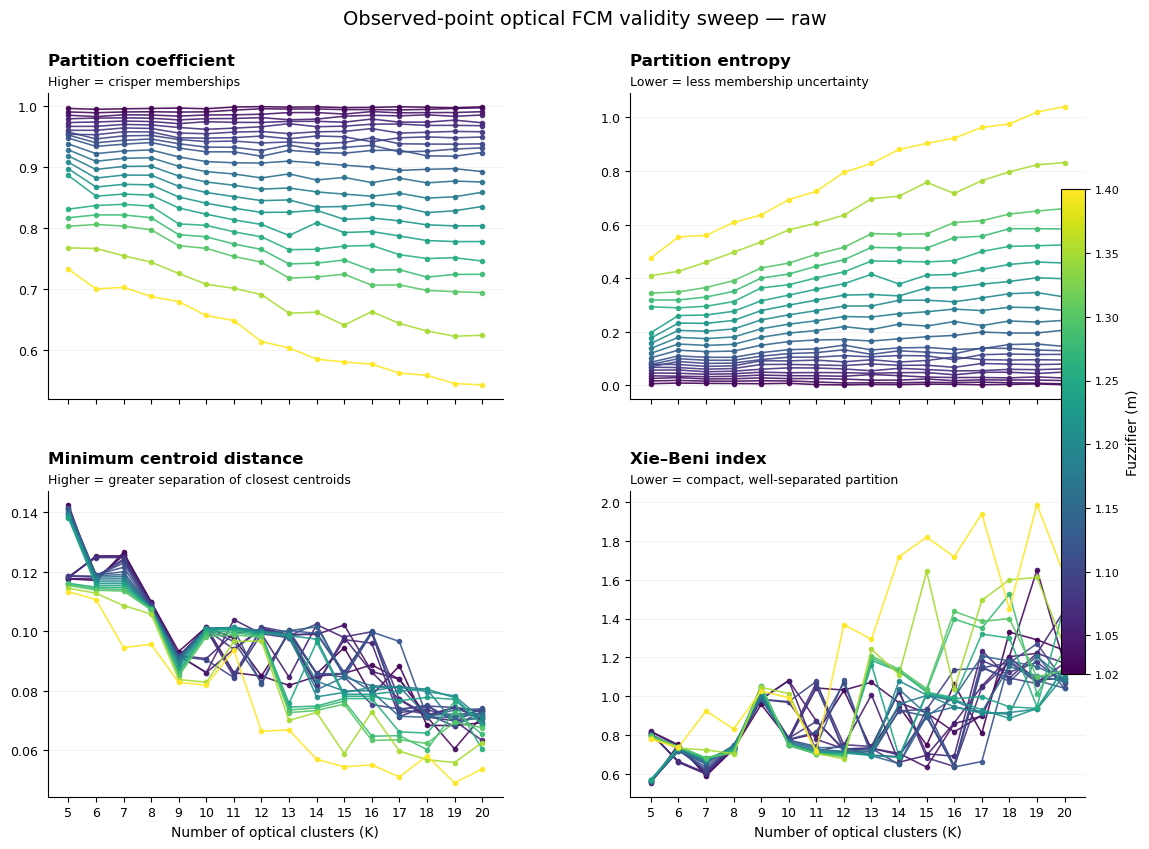

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_raw_PC_PE_MCD_XB.png


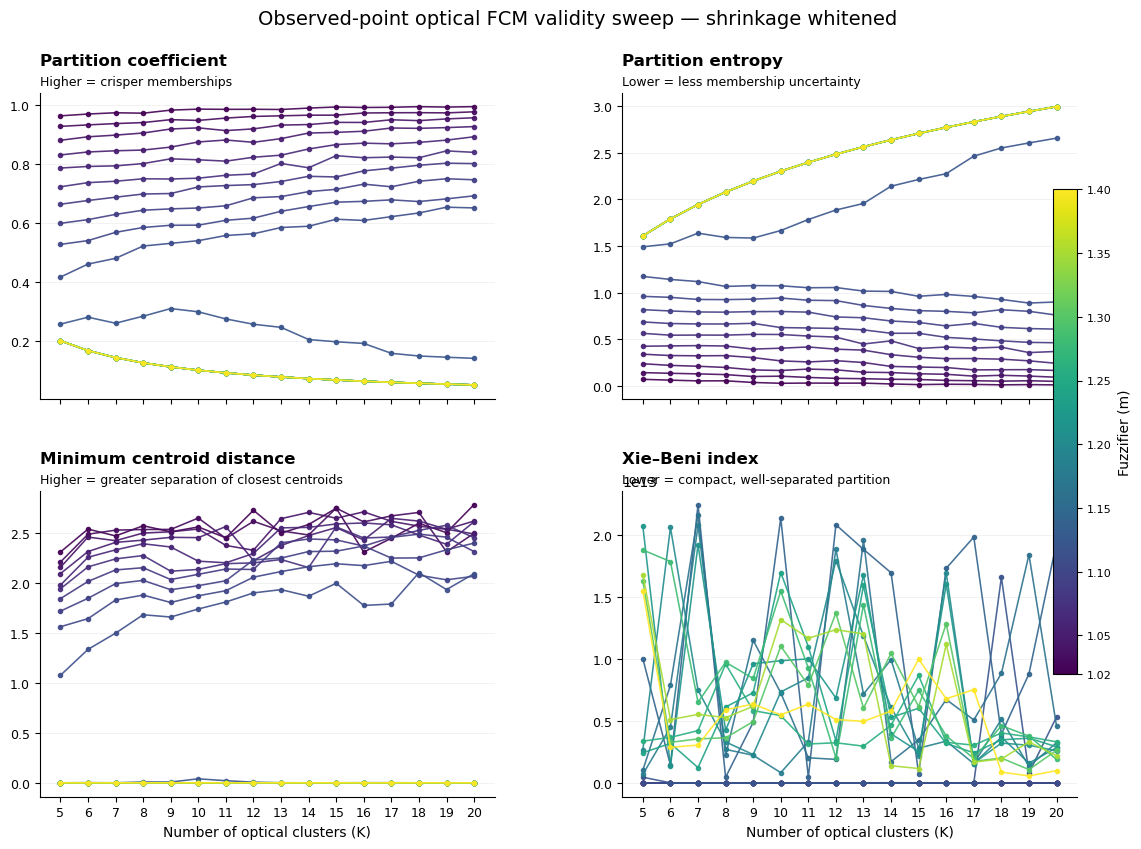

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_shrinkage_whitened_PC_PE_MCD_XB.png


In [18]:
# =============================================================================
# CORE VALIDITY FIGURES
# =============================================================================

validity_specs = [
    (
        "PC",
        "Partition coefficient",
        "Higher = crisper memberships",
    ),
    (
        "PE",
        "Partition entropy",
        "Lower = less membership uncertainty",
    ),
    (
        "MCD",
        "Minimum centroid distance",
        "Higher = greater separation of closest centroids",
    ),
    (
        "XB",
        "Xie–Beni index",
        "Lower = compact, well-separated partition",
    ),
]


for geometry in GEOMETRIES:

    sub_geom = (
        sweep.loc[
            sweep["geometry"].eq(
                geometry
            )
        ]
        .copy()
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            12.5,
            8.8,
        ),
        sharex=True,
    )

    axes = axes.ravel()

    for ax, (
        metric,
        title,
        subtitle,
    ) in zip(
        axes,
        validity_specs,
    ):

        plot_metric_lines(
    ax,
    sub_geom,
    metric,
)

        style_panel(
            ax,
            title,
            subtitle,
        )

    finish_four_panel_figure(
        fig,
        axes,
        (
            "Observed-point optical FCM validity sweep — "
            + geometry.replace(
                "_",
                " ",
            )
        ),
    )

    path = (
        OUTPUT_DIR
        / f"Optical_FCM_{geometry}_PC_PE_MCD_XB.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        path
    )


## 8. Occupancy and restart-stability figures


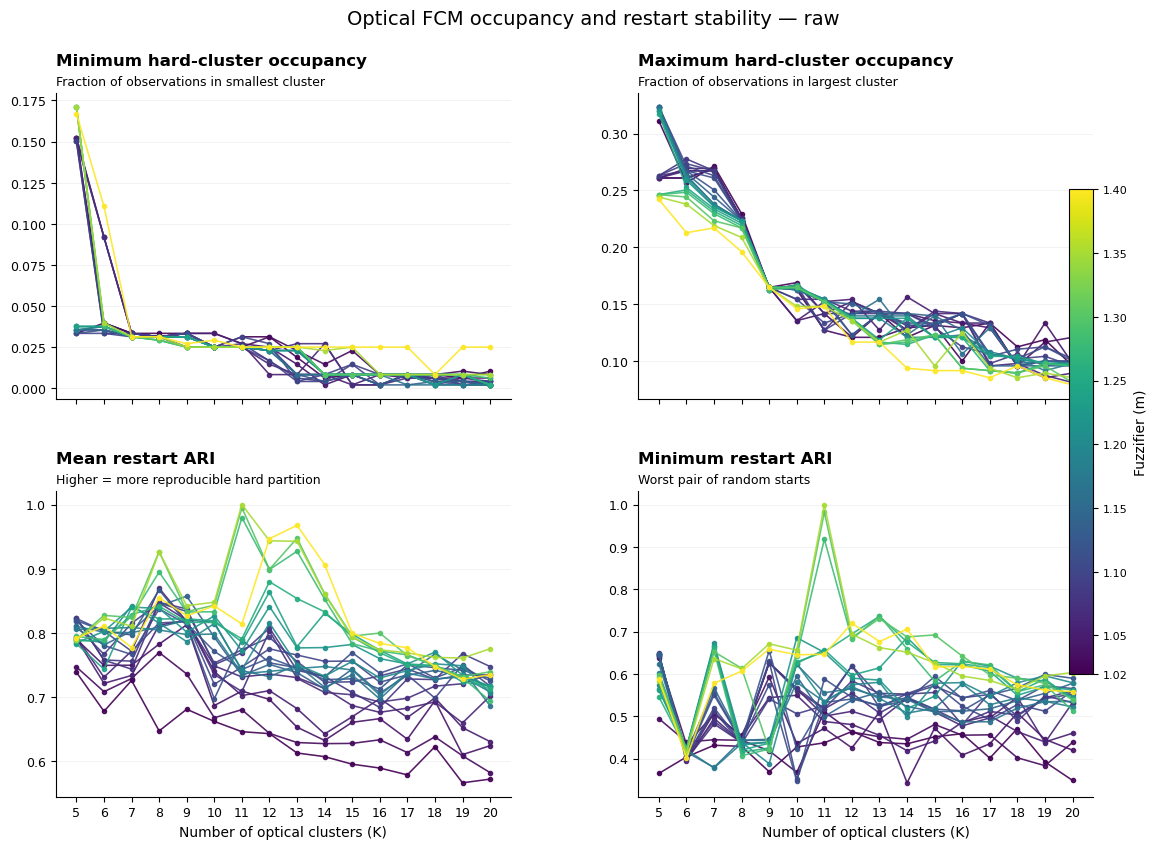

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_raw_occupancy_restartARI.png


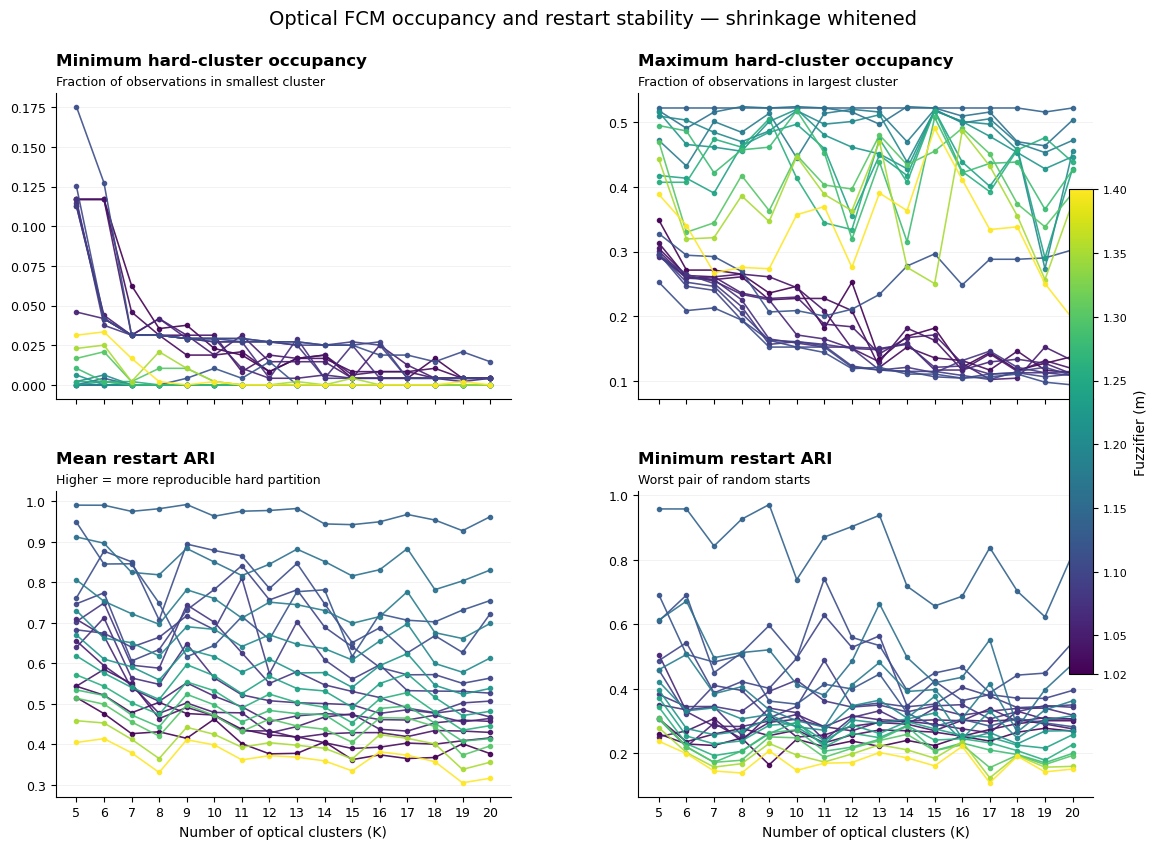

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_shrinkage_whitened_occupancy_restartARI.png


In [19]:
# =============================================================================
# OCCUPANCY + RESTART STABILITY FIGURES
# =============================================================================

stability_specs = [
    (
        "min_occupancy_fraction",
        "Minimum hard-cluster occupancy",
        "Fraction of observations in smallest cluster",
    ),
    (
        "max_occupancy_fraction",
        "Maximum hard-cluster occupancy",
        "Fraction of observations in largest cluster",
    ),
    (
        "restart_ARI_mean",
        "Mean restart ARI",
        "Higher = more reproducible hard partition",
    ),
    (
        "restart_ARI_min",
        "Minimum restart ARI",
        "Worst pair of random starts",
    ),
]


for geometry in GEOMETRIES:

    sub_geom = (
        sweep.loc[
            sweep["geometry"].eq(
                geometry
            )
        ]
        .copy()
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            12.5,
            8.8,
        ),
        sharex=True,
    )

    axes = axes.ravel()

    for ax, (
        metric,
        title,
        subtitle,
    ) in zip(
        axes,
        stability_specs,
    ):

        plot_metric_lines(
    ax,
    sub_geom,
    metric,
)

        style_panel(
            ax,
            title,
            subtitle,
        )

    finish_four_panel_figure(
        fig,
        axes,
        (
            "Optical FCM occupancy and restart stability — "
            + geometry.replace(
                "_",
                " ",
            )
        ),
    )

    path = (
        OUTPUT_DIR
        / f"Optical_FCM_{geometry}_occupancy_restartARI.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        path
    )


## 9. External correspondence figures

ARI/NMI remain downstream descriptive diagnostics and do not determine the optical solution.


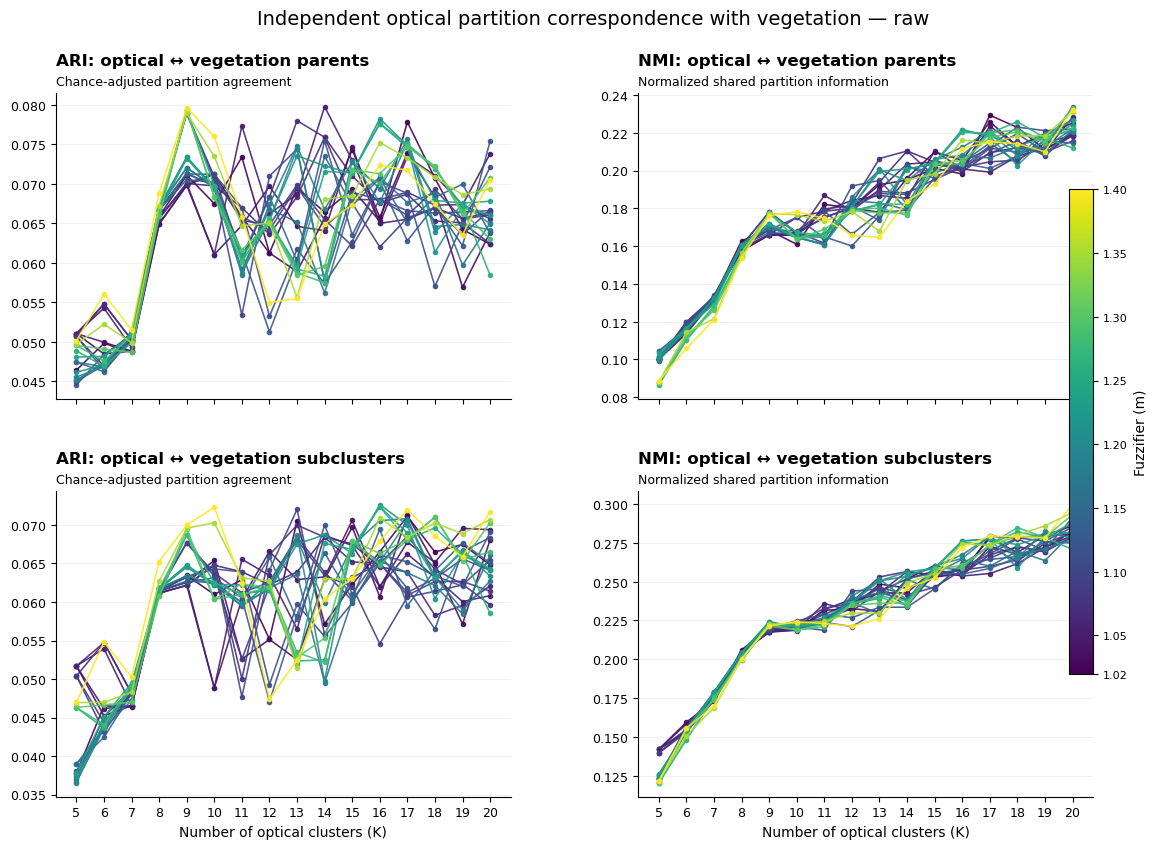

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_raw_external_ARI_NMI.png


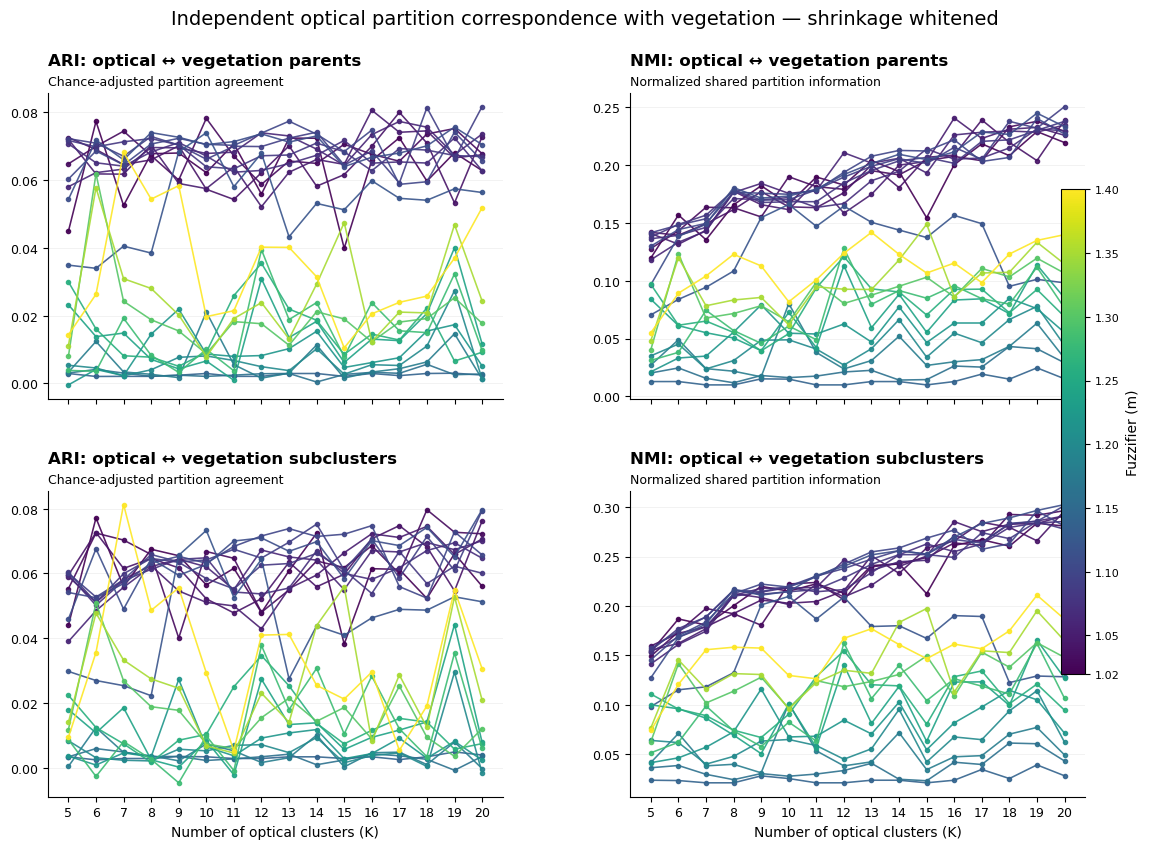

Wrote: A:\NCA_DATA\Validation\Optical_Clustering_Preliminary\Metric_Sensitivity_Raw_Whitened\Optical_FCM_shrinkage_whitened_external_ARI_NMI.png


In [20]:
# =============================================================================
# EXTERNAL CORRESPONDENCE FIGURES
# =============================================================================

external_specs = [
    (
        "ARI_parent",
        "ARI: optical ↔ vegetation parents",
        "Chance-adjusted partition agreement",
    ),
    (
        "NMI_parent",
        "NMI: optical ↔ vegetation parents",
        "Normalized shared partition information",
    ),
    (
        "ARI_subcluster",
        "ARI: optical ↔ vegetation subclusters",
        "Chance-adjusted partition agreement",
    ),
    (
        "NMI_subcluster",
        "NMI: optical ↔ vegetation subclusters",
        "Normalized shared partition information",
    ),
]


for geometry in GEOMETRIES:

    sub_geom = (
        sweep.loc[
            sweep["geometry"].eq(
                geometry
            )
        ]
        .copy()
    )

    if not all(
        metric in sub_geom.columns
        for metric, _, _ in external_specs
    ):

        print(
            geometry,
            ": vegetation labels unavailable; external figure skipped."
        )

        continue

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(
            12.5,
            8.8,
        ),
        sharex=True,
    )

    axes = axes.ravel()

    for ax, (
        metric,
        title,
        subtitle,
    ) in zip(
        axes,
        external_specs,
    ):

        plot_metric_lines(
    ax,
    sub_geom,
    metric,
)

        style_panel(
            ax,
            title,
            subtitle,
        )

    finish_four_panel_figure(
        fig,
        axes,
        (
            "Independent optical partition correspondence with vegetation — "
            + geometry.replace(
                "_",
                " ",
            )
        ),
    )

    path = (
        OUTPUT_DIR
        / f"Optical_FCM_{geometry}_external_ARI_NMI.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Wrote:",
        path
    )


## 10. Metric matrices by geometry

These make it easier to inspect the larger sweep numerically when the line plots become dense.


In [11]:
# =============================================================================
# PIVOT TABLES
# =============================================================================

matrix_metrics = [
    "PC",
    "PE",
    "MCD",
    "XB",
    "min_occupancy_n",
    "max_occupancy_n",
    "restart_ARI_mean",
    "restart_ARI_min",
    "ARI_parent",
    "NMI_parent",
    "ARI_subcluster",
    "NMI_subcluster",
]


for geometry in GEOMETRIES:

    print(
        "\n"
        + "#" * 100
    )

    print(
        "METRIC MATRICES:",
        geometry
    )

    print(
        "#" * 100
    )

    sub_geom = sweep.loc[
        sweep["geometry"].eq(
            geometry
        )
    ]

    for metric in matrix_metrics:

        if metric not in sub_geom.columns:
            continue

        print(
            "\n",
            metric
        )

        display(
            sub_geom.pivot(
                index="m",
                columns="K",
                values=metric,
            ).round(4)
        )



####################################################################################################
METRIC MATRICES: raw
####################################################################################################

 PC


K,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
m,,,,,,,,,,,,,,,,
1.02,0.9962,0.9949,0.9956,0.9962,0.9969,0.9957,0.9986,0.9992,0.9984,0.9988,0.9976,0.9980,0.9990,0.9983,0.9974,0.9989
1.03,0.9905,0.9892,0.9905,0.9908,0.9903,0.9907,0.9934,0.9958,0.9952,0.9954,0.9943,0.9944,0.9939,0.9947,0.9963,0.9973
1.04,0.9852,0.9828,0.9858,0.9855,0.9837,0.9856,0.9858,0.9868,0.9894,0.9895,0.9870,0.9911,0.9890,0.9894,0.9895,0.9909
1.05,0.9793,0.9804,0.9808,0.9802,0.9775,0.9795,0.9797,0.9812,0.9776,0.9788,0.9835,0.9850,0.9840,0.9858,0.9833,0.9855
1.06,0.9732,0.9740,0.9756,0.9748,0.9713,0.9745,0.9734,0.9733,0.9751,0.9751,0.9737,0.9789,0.9738,0.9738,0.9771,0.9728
1.07,0.9668,0.9669,0.9701,0.9692,0.9651,0.9620,0.9639,0.9662,0.9713,0.9663,0.9672,0.9704,0.9707,0.9684,0.9685,0.9679
1.08,0.9603,0.9604,0.9642,0.9635,0.9559,0.9548,0.9575,0.9585,0.9550,0.9580,0.9586,0.9633,0.9558,0.9572,0.9586,0.9580
1.09,0.9538,0.9533,0.9580,0.9577,0.9481,0.9476,0.9483,0.9510,0.9466,0.9511,0.9498,0.9416,0.9482,0.9496,0.9482,0.9494
1.10,0.9576,0.9463,0.9513,0.9520,0.9453,0.9419,0.9427,0.9396,0.9413,0.9385,0.9405,0.9480,0.9383,0.9378,0.9377,0.9382



 PE


K,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
m,,,,,,,,,,,,,,,,
1.02,0.0067,0.0092,0.0079,0.0074,0.0066,0.0082,0.0034,0.0023,0.0039,0.0032,0.0051,0.0045,0.0028,0.0042,0.0059,0.0028
1.03,0.0170,0.0190,0.0162,0.0163,0.0177,0.0169,0.0133,0.0096,0.0099,0.0099,0.0120,0.0106,0.0124,0.0104,0.0085,0.0062
1.04,0.0263,0.0296,0.0242,0.0252,0.0284,0.0258,0.0259,0.0240,0.0199,0.0200,0.0244,0.0180,0.0212,0.0203,0.0205,0.0182
1.05,0.0362,0.0346,0.0329,0.0343,0.0389,0.0366,0.0363,0.0344,0.0409,0.0368,0.0315,0.0296,0.0300,0.0284,0.0322,0.0277
1.06,0.0466,0.0458,0.0418,0.0437,0.0496,0.0476,0.0483,0.0479,0.0456,0.0479,0.0484,0.0400,0.0493,0.0495,0.0448,0.0501
1.07,0.0573,0.0579,0.0512,0.0534,0.0608,0.0659,0.0652,0.0618,0.0550,0.0641,0.0596,0.0545,0.0553,0.0603,0.0591,0.0620
1.08,0.0682,0.0670,0.0610,0.0633,0.0785,0.0787,0.0768,0.0744,0.0805,0.0752,0.0758,0.0677,0.0821,0.0797,0.0781,0.0799
1.09,0.0794,0.0783,0.0713,0.0734,0.0922,0.0918,0.0947,0.0883,0.0961,0.0876,0.0932,0.1063,0.0967,0.0950,0.0962,0.0950
1.10,0.0704,0.0894,0.0823,0.0837,0.0966,0.1058,0.1058,0.1113,0.1069,0.1119,0.1106,0.0963,0.1150,0.1174,0.1158,0.1162



 MCD


...

K,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
m,,,,,,,,,,,,,,,,
1.02,0.1197,0.1568,0.1354,0.1657,0.1821,0.1663,0.1897,0.1828,0.2039,0.1945,0.1545,0.2004,0.2184,0.2082,0.2291,0.2195
1.03,0.1278,0.1432,0.1635,0.1631,0.1552,0.1900,0.1814,0.1790,0.1952,0.1916,0.2041,0.2075,0.2038,0.2331,0.2379,0.2293
1.04,0.1418,0.1394,0.1493,0.1616,0.1771,0.1639,0.1632,0.1761,0.2002,0.1805,0.2068,0.2087,0.2391,0.2197,0.2039,0.2388
1.05,0.1408,0.1316,0.1436,0.1773,0.1658,0.1615,0.1860,0.1584,0.1747,0.2000,0.2031,0.2407,0.2231,0.2311,0.2326,0.2258
1.06,0.1181,0.1333,0.1430,0.1763,0.1841,0.1755,0.1779,0.2107,0.2018,0.2059,0.1932,0.2261,0.2284,0.2295,0.2285,0.2348
1.07,0.1363,0.1393,0.1461,0.1711,0.1701,0.1719,0.1634,0.1667,0.1865,0.1948,0.2140,0.2051,0.2062,0.2149,0.2313,0.2297
1.08,0.1377,0.1487,0.1567,0.1781,0.1677,0.1683,0.1684,0.1846,0.1953,0.2037,0.2066,0.2015,0.2205,0.2219,0.2301,0.2379
1.09,0.1415,0.1482,0.1536,0.1786,0.1697,0.1701,0.1786,0.1897,0.1990,0.2055,0.2014,0.2154,0.2051,0.2379,0.2320,0.2506
1.10,0.1299,0.1443,0.1496,0.1766,0.1757,0.1748,0.1781,0.1938,0.2077,0.2127,0.2122,0.2219,0.2032,0.2066,0.2404,0.2269



 ARI_subcluster


K,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
m,,,,,,,,,,,,,,,,
1.02,0.0440,0.0771,0.0559,0.0675,0.0655,0.0565,0.0616,0.0479,0.0608,0.0724,0.0382,0.0615,0.0613,0.0523,0.0661,0.0561
1.03,0.0553,0.0725,0.0703,0.0659,0.0400,0.0668,0.0647,0.0480,0.0549,0.0638,0.0618,0.0686,0.0599,0.0797,0.0727,0.0722
1.04,0.0595,0.0726,0.0616,0.0646,0.0617,0.0522,0.0478,0.0522,0.0635,0.0559,0.0597,0.0707,0.0748,0.0682,0.0546,0.0762
1.05,0.0590,0.0511,0.0582,0.0624,0.0546,0.0511,0.0500,0.0429,0.0554,0.0595,0.0664,0.0723,0.0711,0.0745,0.0659,0.0707
1.06,0.0390,0.0485,0.0557,0.0621,0.0644,0.0620,0.0550,0.0672,0.0651,0.0641,0.0550,0.0670,0.0666,0.0695,0.0673,0.0701
1.07,0.0596,0.0501,0.0578,0.0613,0.0644,0.0648,0.0543,0.0537,0.0555,0.0670,0.0600,0.0582,0.0618,0.0671,0.0695,0.0647
1.08,0.0603,0.0511,0.0599,0.0646,0.0634,0.0584,0.0552,0.0626,0.0631,0.0662,0.0610,0.0538,0.0668,0.0569,0.0622,0.0601
1.09,0.0601,0.0527,0.0580,0.0659,0.0636,0.0642,0.0675,0.0647,0.0696,0.0752,0.0611,0.0706,0.0586,0.0714,0.0609,0.0794
1.10,0.0541,0.0525,0.0569,0.0632,0.0653,0.0632,0.0683,0.0716,0.0738,0.0714,0.0721,0.0748,0.0559,0.0524,0.0729,0.0657



 NMI_subcluster


K,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
m,,,,,,,,,,,,,,,,
1.02,0.1535,0.1868,0.1807,0.2002,0.2198,0.2150,0.2224,0.2130,0.2408,0.2428,0.2124,0.2613,0.2670,0.2605,0.2837,0.2809
1.03,0.1491,0.1738,0.1974,0.1921,0.1804,0.2222,0.2238,0.2062,0.2397,0.2427,0.2490,0.2638,0.2613,0.2926,0.2918,0.2965
1.04,0.1595,0.1723,0.1789,0.1923,0.2059,0.2027,0.2045,0.2153,0.2508,0.2330,0.2586,0.2659,0.2847,0.2796,0.2660,0.2964
1.05,0.1552,0.1621,0.1769,0.2125,0.2084,0.2014,0.2220,0.2091,0.2209,0.2399,0.2505,0.2854,0.2752,0.2828,0.2834,0.2913
1.06,0.1413,0.1611,0.1744,0.2106,0.2179,0.2180,0.2187,0.2464,0.2360,0.2447,0.2462,0.2710,0.2645,0.2827,0.2860,0.2911
1.07,0.1536,0.1683,0.1791,0.2099,0.2140,0.2187,0.2144,0.2165,0.2336,0.2518,0.2627,0.2550,0.2627,0.2795,0.2841,0.2855
1.08,0.1549,0.1771,0.1888,0.2158,0.2119,0.2144,0.2166,0.2282,0.2421,0.2519,0.2520,0.2491,0.2741,0.2682,0.2853,0.2777
1.09,0.1569,0.1746,0.1889,0.2160,0.2145,0.2200,0.2301,0.2379,0.2474,0.2561,0.2523,0.2673,0.2636,0.2836,0.2856,0.3016
1.10,0.1455,0.1699,0.1838,0.2124,0.2221,0.2191,0.2294,0.2423,0.2547,0.2587,0.2687,0.2769,0.2573,0.2630,0.2961,0.2808


## 11. Candidate diagnostics without automatic selection

No solution is selected automatically.

The useful question is whether a candidate region of `(K, m)` simultaneously shows:

- favorable XB and MCD
- non-pathological occupancy
- restart reproducibility
- persistence across both raw and shrinkage-whitened geometry

External vegetation correspondence is inspected only after those internal properties.


In [12]:
# =============================================================================
# CANDIDATE DIAGNOSTIC TABLES
# =============================================================================

def show_extremes(
    sub,
    metric,
    ascending,
    n=15,
):

    cols = [
        c for c in [
            "geometry",
            "K",
            "m",
            "PC",
            "PE",
            "MCD",
            "XB",
            "min_occupancy_n",
            "max_occupancy_n",
            "restart_ARI_mean",
            "restart_ARI_min",
            "ARI_parent",
            "ARI_subcluster",
        ]
        if c in sub.columns
    ]

    display(
        sub.sort_values(
            metric,
            ascending=ascending,
        )[cols].head(
            n
        )
    )


for geometry in GEOMETRIES:

    print(
        "\n"
        + "=" * 100
    )

    print(
        geometry.upper()
    )

    print(
        "=" * 100
    )

    sub = sweep.loc[
        sweep["geometry"].eq(
            geometry
        )
    ]

    print("\nLowest XB")
    show_extremes(
        sub,
        "XB",
        ascending=True,
    )

    print("\nHighest MCD")
    show_extremes(
        sub,
        "MCD",
        ascending=False,
    )

    print("\nHighest restart ARI")
    show_extremes(
        sub,
        "restart_ARI_mean",
        ascending=False,
    )



RAW

Lowest XB


,geometry,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,restart_ARI_min,ARI_parent,ARI_subcluster
0,raw,5,1.02,0.996233,0.006717,0.142644,0.555065,16,149,0.738867,0.364792,0.046399,0.037790
128,raw,5,1.10,0.957606,0.070373,0.141617,0.559509,16,155,0.822508,0.647016,0.044954,0.038022
144,raw,5,1.11,0.952618,0.078603,0.141335,0.560943,16,155,0.819020,0.644488,0.044525,0.037015
160,raw,5,1.12,0.947696,0.086855,0.141033,0.562482,17,155,0.819366,0.643786,0.045105,0.037479
176,raw,5,1.14,0.938033,0.103457,0.140449,0.565195,17,155,0.807239,0.645940,0.047397,0.038975
192,raw,5,1.16,0.928333,0.120517,0.139936,0.567063,17,155,0.810250,0.624288,0.047397,0.038975
208,raw,5,1.18,0.918368,0.138326,0.139461,0.568333,17,154,0.805655,0.601947,0.045534,0.036642
224,raw,5,1.20,0.908061,0.157004,0.138998,0.569220,18,153,0.789621,0.574668,0.045112,0.036522
240,raw,5,1.22,0.897386,0.176610,0.138534,0.569814,18,153,0.784773,0.564279,0.046112,0.037271
256,raw,5,1.24,0.886325,0.197190,0.138066,0.570144,18,152,0.783476,0.561375,0.048046,0.037857



Highest MCD


,geometry,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,restart_ARI_min,ARI_parent,ARI_subcluster
0,raw,5,1.02,0.996233,0.006717,0.142644,0.555065,16,149,0.738867,0.364792,0.046399,0.037790
128,raw,5,1.10,0.957606,0.070373,0.141617,0.559509,16,155,0.822508,0.647016,0.044954,0.038022
144,raw,5,1.11,0.952618,0.078603,0.141335,0.560943,16,155,0.819020,0.644488,0.044525,0.037015
160,raw,5,1.12,0.947696,0.086855,0.141033,0.562482,17,155,0.819366,0.643786,0.045105,0.037479
176,raw,5,1.14,0.938033,0.103457,0.140449,0.565195,17,155,0.807239,0.645940,0.047397,0.038975
192,raw,5,1.16,0.928333,0.120517,0.139936,0.567063,17,155,0.810250,0.624288,0.047397,0.038975
208,raw,5,1.18,0.918368,0.138326,0.139461,0.568333,17,154,0.805655,0.601947,0.045534,0.036642
224,raw,5,1.20,0.908061,0.157004,0.138998,0.569220,18,153,0.789621,0.574668,0.045112,0.036522
240,raw,5,1.22,0.897386,0.176610,0.138534,0.569814,18,153,0.784773,0.564279,0.046112,0.037271
256,raw,5,1.24,0.886325,0.197190,0.138066,0.570144,18,152,0.783476,0.561375,0.048046,0.037857



Highest restart ARI


...

,geometry,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,restart_ARI_min,ARI_parent,ARI_subcluster
367,shrinkage_whitened,20,1.02,0.995366,0.011343,2.782537,2.674705,2,66,0.377464,0.267939,0.062834,0.056055
381,shrinkage_whitened,18,1.03,0.974847,0.051545,2.703689,2.896396,5,70,0.400703,0.291377,0.073634,0.079669
378,shrinkage_whitened,15,1.03,0.966474,0.069292,2.746784,2.916730,4,65,0.390088,0.265026,0.070605,0.061793
362,shrinkage_whitened,15,1.02,0.994100,0.014385,2.745795,2.925706,2,87,0.362526,0.223422,0.039898,0.038187
395,shrinkage_whitened,16,1.04,0.941646,0.125281,2.709661,2.950434,4,56,0.429262,0.301689,0.070001,0.070720
431,shrinkage_whitened,20,1.06,0.893037,0.242537,2.611013,2.966856,2,53,0.464283,0.305532,0.073628,0.070093
399,shrinkage_whitened,20,1.04,0.957597,0.093386,2.617775,2.991835,2,57,0.429724,0.275141,0.072801,0.076172
380,shrinkage_whitened,17,1.03,0.974604,0.056043,2.669310,3.003394,4,56,0.403494,0.273101,0.065598,0.059920
412,shrinkage_whitened,17,1.05,0.922772,0.172132,2.644539,3.054373,6,49,0.433022,0.262878,0.074138,0.071109
413,shrinkage_whitened,18,1.05,0.921597,0.173950,2.617108,3.056424,2,50,0.453420,0.329983,0.074559,0.074541



Highest MCD


,geometry,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,restart_ARI_min,ARI_parent,ARI_subcluster
367,shrinkage_whitened,20,1.02,0.995366,0.011343,2.782537,2.674705,2,66,0.377464,0.267939,0.062834,0.056055
378,shrinkage_whitened,15,1.03,0.966474,0.069292,2.746784,2.916730,4,65,0.390088,0.265026,0.070605,0.061793
362,shrinkage_whitened,15,1.02,0.994100,0.014385,2.745795,2.925706,2,87,0.362526,0.223422,0.039898,0.038187
359,shrinkage_whitened,12,1.02,0.986398,0.029877,2.725269,3.138776,4,121,0.376842,0.237296,0.055865,0.047890
395,shrinkage_whitened,16,1.04,0.941646,0.125281,2.709661,2.950434,4,56,0.429262,0.301689,0.070001,0.070720
393,shrinkage_whitened,14,1.04,0.934490,0.143741,2.703914,3.076455,9,87,0.426022,0.289775,0.058220,0.055885
381,shrinkage_whitened,18,1.03,0.974847,0.051545,2.703689,2.896396,5,70,0.400703,0.291377,0.073634,0.079669
380,shrinkage_whitened,17,1.03,0.974604,0.056043,2.669310,3.003394,4,56,0.403494,0.273101,0.065598,0.059920
373,shrinkage_whitened,10,1.03,0.948581,0.104711,2.647561,3.410836,9,109,0.472618,0.271300,0.078259,0.066776
394,shrinkage_whitened,15,1.04,0.941852,0.130482,2.645803,3.156615,3,78,0.429030,0.269556,0.061637,0.059748



Highest restart ARI


,geometry,K,m,PC,PE,MCD,XB,min_occupancy_n,max_occupancy_n,restart_ARI_mean,restart_ARI_min,ARI_parent,ARI_subcluster
532,shrinkage_whitened,9,1.14,0.111111,2.197225,2.108142e-06,4.879625e+12,0,250,0.992294,0.971847,0.002415,0.003482
528,shrinkage_whitened,5,1.14,0.200000,1.609438,1.533553e-06,1.001213e+13,0,250,0.990810,0.958227,0.002923,0.003362
529,shrinkage_whitened,6,1.14,0.166667,1.791759,3.995076e-06,1.438099e+12,0,250,0.990598,0.958130,0.002050,0.002416
536,shrinkage_whitened,13,1.14,0.076923,2.564949,1.045390e-06,1.884826e+13,0,250,0.982503,0.938565,0.002923,0.003362
531,shrinkage_whitened,8,1.14,0.125000,2.079442,7.046898e-06,4.439679e+11,0,250,0.982014,0.926253,0.002082,0.002842
535,shrinkage_whitened,12,1.14,0.083333,2.484907,3.722611e-07,2.083027e+13,0,250,0.977647,0.903465,0.002082,0.002842
534,shrinkage_whitened,11,1.14,0.090909,2.397895,6.891874e-06,4.439260e+11,0,250,0.975840,0.870853,0.002082,0.002842
530,shrinkage_whitened,7,1.14,0.142857,1.945910,7.560223e-07,2.246293e+13,0,250,0.975466,0.842941,0.002082,0.002842
540,shrinkage_whitened,17,1.14,0.058824,2.833213,7.959730e-07,1.983889e+13,0,250,0.967817,0.837892,0.002299,0.002509
533,shrinkage_whitened,10,1.14,0.100000,2.302585,3.933811e-07,2.136880e+13,0,250,0.963522,0.738874,0.002928,0.003365


## 12. Cross-geometry robustness table

For each `(K, m)`, this table places the raw and whitened diagnostics side-by-side. It is useful for asking whether the same structural break persists despite changing the distance metric.


In [13]:
# =============================================================================
# RAW ↔ WHITENED SIDE-BY-SIDE DIAGNOSTICS
# =============================================================================

comparison_metrics = [
    "PC",
    "PE",
    "MCD",
    "XB",
    "min_occupancy_n",
    "max_occupancy_n",
    "restart_ARI_mean",
    "ARI_parent",
    "ARI_subcluster",
]

comparison = sweep.pivot(
    index=[
        "K",
        "m",
    ],
    columns="geometry",
    values=comparison_metrics,
)

comparison = comparison.sort_index()

display(
    comparison.round(4)
)


PC                         PE                        MCD                         XB                    min_occupancy_n                    max_occupancy_n                    restart_ARI_mean                    ARI_parent                     \
geometry     raw shrinkage_whitened     raw shrinkage_whitened     raw shrinkage_whitened     raw shrinkage_whitened             raw shrinkage_whitened             raw shrinkage_whitened              raw shrinkage_whitened        raw shrinkage_whitened   
K  m                                                                                                                                                                                                                                                           
5  1.02   0.9962             0.9641  0.0067             0.0710  0.1426             2.3076  0.5551       4.972300e+00            16.0               56.0           149.0              167.0           0.7389             0.5159     0.0464             0.0449   
   1.03   0.9905             0.9283  0.0170             0.1430  0.1176             2.2069  0.8195       5.418900e+00            73.0               56.0           125.0              150.0           0.7472             0.5437     0.0510             0.0648   
   1.04   0.9852             0.8811  0.0263             0.2384  0.1177             2.1533  0.8180       5.667900e+00            73.0               56.0           125.0              146.0           0.7902             0.5438     0.0510             0.0726   
   1.05   0.9793             0.8313  0.0362             0.3407  0.1179             2.0915  0.8149       5.973700e+00            73.0               54.0           125.0              144.0           0.7915             0.6557     0.0510             0.0720   
   1.06   0.9732             0.7868  0.0466             0.4259  0.1181             1.9769  0.8112       6.637000e+00            73.0               22.0           125.0              140.0           0.7940             0.7091     0.0510             0.0581   
...          ...                ...     ...                ...     ...                ...     ...                ...             ...                ...             ...                ...              ...                ...        ...                ...   
20 1.26   0.7462             0.0500  0.5246             2.9957  0.0604             0.0000  1.4674       3.310084e+12             1.0                0.0            46.0              210.0           0.7124             0.4464     0.0584             0.0092   
   1.28   0.7243             0.0500  0.5843             2.9957  0.0653             0.0000  1.2368       1.884391e+12             3.0                0.0            46.0              204.0           0.6941             0.4145     0.0630             0.0097   
   1.30   0.6944             0.0500  0.6601             2.9957  0.0676             0.0000  1.1327       2.623495e+12             4.0                0.0            39.0              187.0           0.7397             0.3964     0.0708             0.0178   
   1.35   0.6244             0.0500  0.8319             2.9957  0.0626             0.0000  1.2546       2.178719e+12             4.0                0.0            41.0              180.0           0.7755             0.3561     0.0693             0.0244   
   1.40   0.5430             0.0500  1.0405             2.9957  0.0536             0.0000  1.6207       9.829002e+11            12.0                0.0            38.0               94.0           0.7351             0.3166     0.0705             0.0519   

         ARI_subcluster                     
geometry            raw shrinkage_whitened  
K  m                                        
5  1.02          0.0378             0.0440  
   1.03          0.0517             0.0553  
   1.04          0.0517             0.0595  
   1.05          0.0517             0.0590  
   1.06          0.0517             0.0390  
...                 ...                ...  
20 1.26          0.0585 

## 13. Manual selected-solution export

After comparing the two geometries, set one geometry, K, and m.

The selected export retains:

- hard label
- full fuzzy membership vector
- membership margin
- centroid distances
- assigned-centroid distance
- original vegetation labels
- centroids in the fitted geometry

For the shrinkage-whitened solution, the saved feature center and whitening matrix are required for future pixel classification.


In [14]:
# =============================================================================
# MANUAL SELECTION
# =============================================================================

SELECTED_GEOMETRY = None
SELECTED_K = None
SELECTED_M = None

# Example only:
# SELECTED_GEOMETRY = "shrinkage_whitened"
# SELECTED_K = 10
# SELECTED_M = 1.08


if (
    SELECTED_GEOMETRY is None
    or SELECTED_K is None
    or SELECTED_M is None
):

    print(
        "No solution selected yet. "
        "Inspect internal geometry/stability first, then set "
        "SELECTED_GEOMETRY, SELECTED_K, and SELECTED_M."
    )

else:

    key = (
        str(
            SELECTED_GEOMETRY
        ),
        int(
            SELECTED_K
        ),
        float(
            SELECTED_M
        ),
    )

    if key not in best_solutions:
        raise KeyError(
            f"Selected solution {key} was not fitted."
        )

    fit = best_solutions[
        key
    ]

    X_selected = X_BY_GEOMETRY[
        SELECTED_GEOMETRY
    ]

    U = fit["U"]
    centers = fit["centers"]

    hard0 = np.argmax(
        U,
        axis=1,
    )

    hard = (
        hard0 + 1
    )

    sorted_u = np.sort(
        U,
        axis=1,
    )

    max_u = sorted_u[:, -1]

    margin = (
        sorted_u[:, -1]
        - sorted_u[:, -2]
    )

    distances = cdist(
        X_selected,
        centers,
        metric="euclidean",
    )

    assigned_distance = distances[
        np.arange(
            len(df)
        ),
        hard0,
    ]

    selected = df.copy()

    selected[
        "optical_geometry"
    ] = SELECTED_GEOMETRY

    selected[
        "optical_cluster"
    ] = hard

    selected[
        "optical_max_membership"
    ] = max_u

    selected[
        "optical_membership_margin"
    ] = margin

    selected[
        "optical_assigned_centroid_distance"
    ] = assigned_distance

    for j in range(
        int(
            SELECTED_K
        )
    ):

        selected[
            f"optical_membership_{j + 1}"
        ] = U[
            :,
            j,
        ]

        selected[
            f"optical_centroid_distance_{j + 1}"
        ] = distances[
            :,
            j,
        ]

    centroid_df = pd.DataFrame(
        centers,
        columns=IA_COLS,
    )

    centroid_df.insert(
        0,
        "optical_cluster",
        np.arange(
            1,
            int(
                SELECTED_K
            ) + 1,
        ),
    )

    tag = (
        f"{SELECTED_GEOMETRY}_K{int(SELECTED_K):02d}_m"
        + f"{float(SELECTED_M):.2f}".replace(
            ".",
            "p",
        )
    )

    selected_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{tag}_assignments.csv"
    )

    centroid_path = (
        OUTPUT_DIR
        / f"Optical_FCM_{tag}_centroids_fit_geometry.csv"
    )

    selected.to_csv(
        selected_path,
        index=False,
    )

    centroid_df.to_csv(
        centroid_path,
        index=False,
    )

    print(
        "Selected:",
        tag
    )

    print(
        "Wrote:",
        selected_path
    )

    print(
        "Wrote:",
        centroid_path
    )


No solution selected yet. Inspect internal geometry/stability first, then set SELECTED_GEOMETRY, SELECTED_K, and SELECTED_M.


## Interpretation

The critical comparison is not simply which geometry produces the numerically smallest XB. XB, MCD, and the FCM objective are representation-dependent because the transformation changes the metric itself.

Instead ask whether **structural conclusions persist**:

- Is there a repeated break in validity near the same K?
- Do tiny/singleton clusters appear at the same K?
- Is restart stability locally high at the same K?
- Does the favored K remain similar across raw and shrinkage-whitened space?
- Does the parent/subcluster correspondence behave similarly after the optical solution is selected internally?

If the same K-region persists across raw, z-score, and shrinkage-whitened space, that is much stronger evidence that the structure is intrinsic to the harmonic observations rather than induced by one scaling assumption.
